# **Child Well-being - Minimum Dominant Set visualization**<br/>
**University: University of Milano-Bicocca**  
**Master's Degree: Data Science (A.Y. 2025/2026)**  
**Course: Data Science Lab**  

In [37]:
import sys; sys.path.insert(0, "..")
import pickle

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

In [38]:
path = f"../data/050_posets_macro_dimensions_3_level.pkl"
with open(path, "rb") as f:
    data = pickle.load(f)

Nei Poset, se un nodo (Nazione A) domina un altro nodo (Nazione B), significa che la Nazione A ha performance uguali o superiori in tutti gli indicatori rispetto alla Nazione B. L'MDS ci dice qual è il numero minimo di "leader" necessari per coprire (superare) tutti gli altri.
ind_2015 (MDS: 1) - Il Leader Assoluto:
L'Estonia (EST_2015) da sola copre l'intero set. Questo è un risultato raro e fortissimo. Significa che l'Estonia, in quell'anno e per quel gruppo di indicatori, aveva un profilo tale da essere uguale o superiore a tutte le altre 15 nazioni. Non c'era nessun paese con una combinazione di valori che potesse "sfidare" l'Estonia su tutta la linea.
ind_2018 (MDS: 2) - La Polarizzazione:
Qui servono due nazioni: Lituania (LTU_2018) e Italia (ITA_2018). Cosa significa? Che questi due paesi offrono due "modelli di eccellenza" diversi e incomparabili tra loro. L'Italia sarà forte in alcuni indicatori dove la Lituania è debole, e viceversa. Tuttavia, mettendole insieme, qualsiasi altro paese europeo del dataset risulta inferiore (o uguale) ad almeno una delle due.
exp_2018 (MDS: 4) ed exp_2015 (MDS: 6) - L'Incomparabilità Diffusa:
Negli scenari "exp" la situazione si complica. Un MDS di 6 nazioni significa che non ci sono leader chiari. I profili dei paesi sono molto "frastagliati": magari la Svezia eccelle nell'indicatore X ma crolla nell'Y, mentre la Lettonia fa l'opposto. C'è molta incomparabilità. Più l'MDS è grande, meno il set di indicatori riesce a creare una gerarchia chiara tra le nazioni.

In [39]:
def get_mds_elements(poset_dict: dict) -> set:
    """
    Extract the Minimum Dominant Set (MDS) from a poset result.

    The MDS consists of all maximal elements — those not dominated
    by any other element in the certain dominance relation.
    """
    G = nx.DiGraph()
    G.add_nodes_from(poset_dict["elements"])
    G.add_edges_from(poset_dict["dom_certain"])

    # Maximal elements: nodes with in-degree 0 in the dominance graph
    # (no one dominates them)
    maximals = {n for n, deg in G.in_degree() if deg == 0}
    return maximals

def shorten_country(label: str, sep: str = "_") -> str:
    """'SWE_2015' → 'SWE'"""
    return label.split(sep)[0] if sep in label else label

In [40]:
mds_2015 = get_mds_elements(data["ind_2015"])
mds_2018 = get_mds_elements(data["ind_2018"])

clean_2015 = {shorten_country(c) for c in mds_2015}
clean_2018 = {shorten_country(c) for c in mds_2018}

stable = clean_2015 & clean_2018
exited = clean_2015 - clean_2018
entered = clean_2018 - clean_2015
jaccard = len(stable) / len(clean_2015 | clean_2018) if clean_2015 | clean_2018 else 0

print("=" * 55)
print("  MDS LEADERSHIP STABILITY ANALYSIS")
print("=" * 55)
print(f"  Jaccard Similarity: {jaccard:.2f}  (1.0 = identical, 0.0 = disjoint)")
print(f"  Stable leaders (both years):  {sorted(stable)}")
print(f"  Exited leadership in 2018:    {sorted(exited) if exited else 'None'}")
print(f"  New leaders in 2018:          {sorted(entered) if entered else 'None'}")
print()

  MDS LEADERSHIP STABILITY ANALYSIS
  Jaccard Similarity: 0.00  (1.0 = identical, 0.0 = disjoint)
  Stable leaders (both years):  []
  Exited leadership in 2018:    ['EST']
  New leaders in 2018:          ['ITA', 'LTU']



In [41]:
def draw_hasse_on_axis(
    ax,
    poset_dict: dict,
    title: str,
    font_size: int = 9,
    arrow_size: int = 15,
    layer_spacing: float = 8.0,
    color_mds: tuple = ("#FFECEC", "#FF7675", "#D63031"),
    color_dom: tuple = ("#F0F8FF", "#74B9FF", "#0984E3"),
    shorten_labels: bool = True,
    label_sep: str = "_",
):
    """
    Draw a Hasse diagram on a matplotlib Axes, highlighting MDS elements.

    Handles equivalence classes (nodes with identical dominance profiles)
    via graph condensation.

    Parameters
    ----------
    ax : matplotlib Axes
    poset_dict : dict
        Output of poset_from_polars().
    title : str
    color_mds : tuple of (bg, border, text) for MDS elements
    color_dom : tuple of (bg, border, text) for dominated elements
    shorten_labels : bool
        Shorten 'SWE_2015' → 'SWE' inside node boxes.
    """
    # Build dominance graph and condense equivalence classes
    G = nx.DiGraph()
    G.add_nodes_from(poset_dict["elements"])
    G.add_edges_from(poset_dict["dom_certain"])
    C = nx.condensation(G)
    TR_C = nx.transitive_reduction(C)

    # Build Hasse graph on condensed nodes
    Hasse_G = nx.DiGraph()
    mapping = {}
    for n in C.nodes():
        members = sorted(C.nodes[n]["members"])
        if shorten_labels:
            display = [m.split(label_sep)[0] if label_sep in m else m for m in members]
        else:
            display = members
        label = "\n".join(display)
        mapping[n] = label
        Hasse_G.add_node(label, raw_members=members)

    for u, v in TR_C.edges():
        Hasse_G.add_edge(mapping[u], mapping[v])

    # MDS: source nodes in condensation (in-degree 0 = no one dominates them)
    mds_members = set()
    for n, deg in C.in_degree():
        if deg == 0:
            mds_members.update(C.nodes[n]["members"])

    # Layer assignment (longest-path from sources)
    layers = {node: 0 for node in Hasse_G.nodes()}
    sources = [n for n in Hasse_G.nodes() if Hasse_G.in_degree(n) == 0]
    for src in sources:
        for target, length in nx.single_source_shortest_path_length(Hasse_G, src).items():
            layers[target] = max(layers[target], length)

    # Group by layer
    layer_nodes = {}
    for node, layer in layers.items():
        layer_nodes.setdefault(layer, []).append(node)

    # Position: MDS on top, most connected nodes centered
    max_layer = max(layer_nodes.keys()) if layer_nodes else 0
    pos = {}
    for layer, nodes_in_layer in layer_nodes.items():
        y = max_layer - layer
        n_nodes = len(nodes_in_layer)
        nodes_in_layer.sort(key=lambda x: -Hasse_G.out_degree(x))
        for i, node in enumerate(nodes_in_layer):
            x = (i - (n_nodes - 1) / 2.0) * (layer_spacing / max(1, n_nodes))
            pos[node] = (x, y)

    # Draw edges
    if Hasse_G.edges():
        nx.draw_networkx_edges(
            Hasse_G, pos, ax=ax,
            edge_color="#BDC3C7",
            width=1.5,
            arrows=True,
            arrowsize=arrow_size,
            arrowstyle="-|>",
            node_size=3500,
            connectionstyle="arc3,rad=0.08",
        )

    # Draw nodes as text boxes
    for node in Hasse_G.nodes():
        raw = Hasse_G.nodes[node].get("raw_members", [])
        is_mds = any(m in mds_members for m in raw)
        bg, border, text_col = color_mds if is_mds else color_dom

        ax.text(
            pos[node][0], pos[node][1], node,
            ha="center", va="center",
            fontsize=font_size, fontweight="bold", color=text_col,
            bbox=dict(
                boxstyle="round,pad=0.6,rounding_size=0.4",
                facecolor=bg, edgecolor=border, linewidth=1.5,
            ),
        )

    ax.set_title(title, fontsize=14, fontweight="bold", color="#2C3E50", pad=15)
    ax.axis("off")


def plot_mds_grid(
    data: dict,
    titles: dict | None = None,
    suptitle: str = "MDS and Pareto Frontier Analysis (2015 vs 2018)",
    figsize: tuple = (22, 18),
    save_path: str | None = None,
    dpi: int = 200,
    **hasse_kwargs,
):
    """
    2×2 grid of Hasse diagrams with MDS highlighting.

    Parameters
    ----------
    data : dict
        Keys → poset_dict, e.g. {'ind_2015': ..., 'ind_2018': ..., ...}
    titles : dict, optional
        {key: display_title}. Auto-generated if None.
    """
    keys = sorted(data.keys())
    n = len(keys)
    ncols = min(n, 2)
    nrows = (n + ncols - 1) // ncols

    if titles is None:
        titles = {k: k.replace("_", " ").title() for k in keys}

    fig, axes = plt.subplots(
        nrows, ncols, figsize=figsize, facecolor="#F8F9FA",
    )
    if n == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, key in enumerate(keys):
        draw_hasse_on_axis(
            axes[i], data[key],
            title=titles.get(key, key),
            **hasse_kwargs,
        )

    # Hide unused axes
    for i in range(n, len(axes)):
        axes[i].set_visible(False)

    # Legend
    patches = [
        mpatches.Patch(
            facecolor="#FFECEC", edgecolor="#FF7675",
            linewidth=2, label="MDS (Maximal classes)",
        ),
        mpatches.Patch(
            facecolor="#F0F8FF", edgecolor="#74B9FF",
            linewidth=2, label="Dominated elements",
        ),
    ]
    fig.legend(
        handles=patches, loc="lower center", ncol=2,
        fontsize=12, frameon=True, facecolor="white",
        edgecolor="#BDC3C7", borderpad=1,
        bbox_to_anchor=(0.5, 0.02),
    )

    fig.suptitle(
        suptitle, fontsize=18, fontweight="bold",
        color="#2C3E50", y=0.98,
    )
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        print(f"Saved to {save_path}")

    plt.show()
    return fig, axes

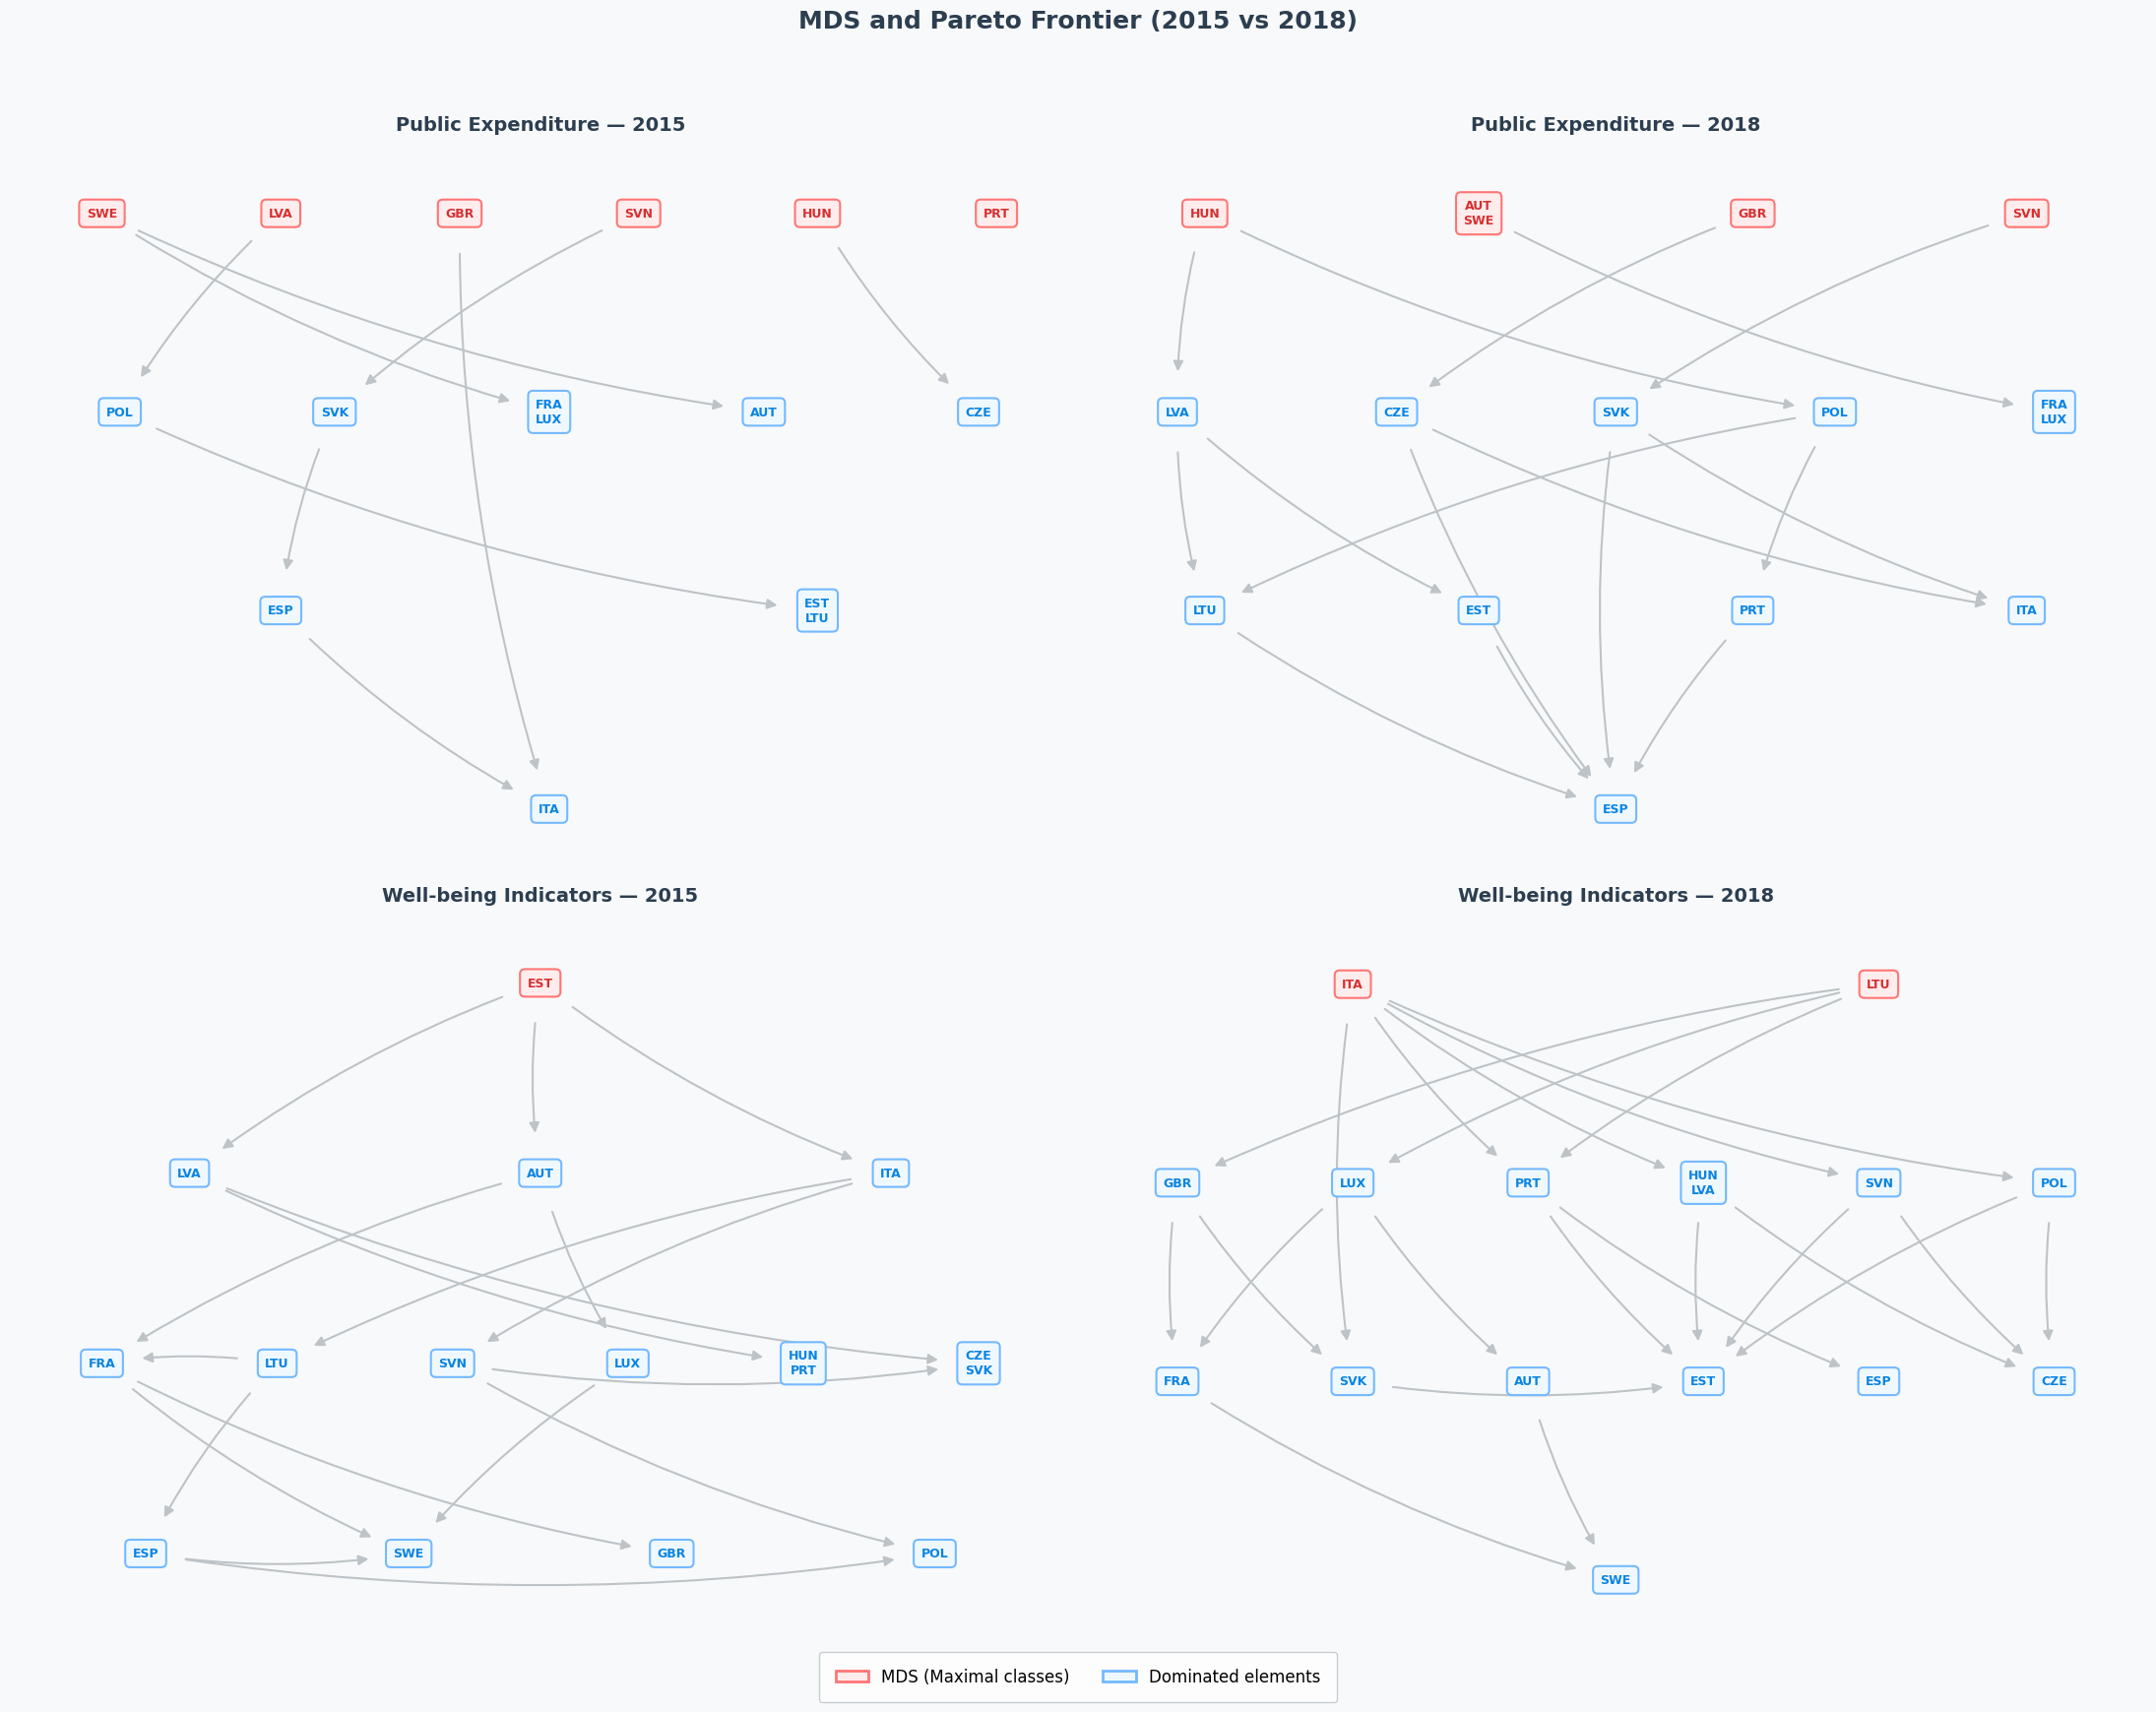

(<Figure size 2200x1800 with 4 Axes>,
 array([<Axes: title={'center': 'Public Expenditure — 2015'}>,
        <Axes: title={'center': 'Public Expenditure — 2018'}>,
        <Axes: title={'center': 'Well-being Indicators — 2015'}>,
        <Axes: title={'center': 'Well-being Indicators — 2018'}>],
       dtype=object))

In [42]:
plot_mds_grid(
    data,
    titles={
        "exp_2015": "Public Expenditure — 2015",
        "exp_2018": "Public Expenditure — 2018",
        "ind_2015": "Well-being Indicators — 2015",
        "ind_2018": "Well-being Indicators — 2018",
    },
    suptitle="MDS and Pareto Frontier (2015 vs 2018)",
    shorten_labels=True,
)

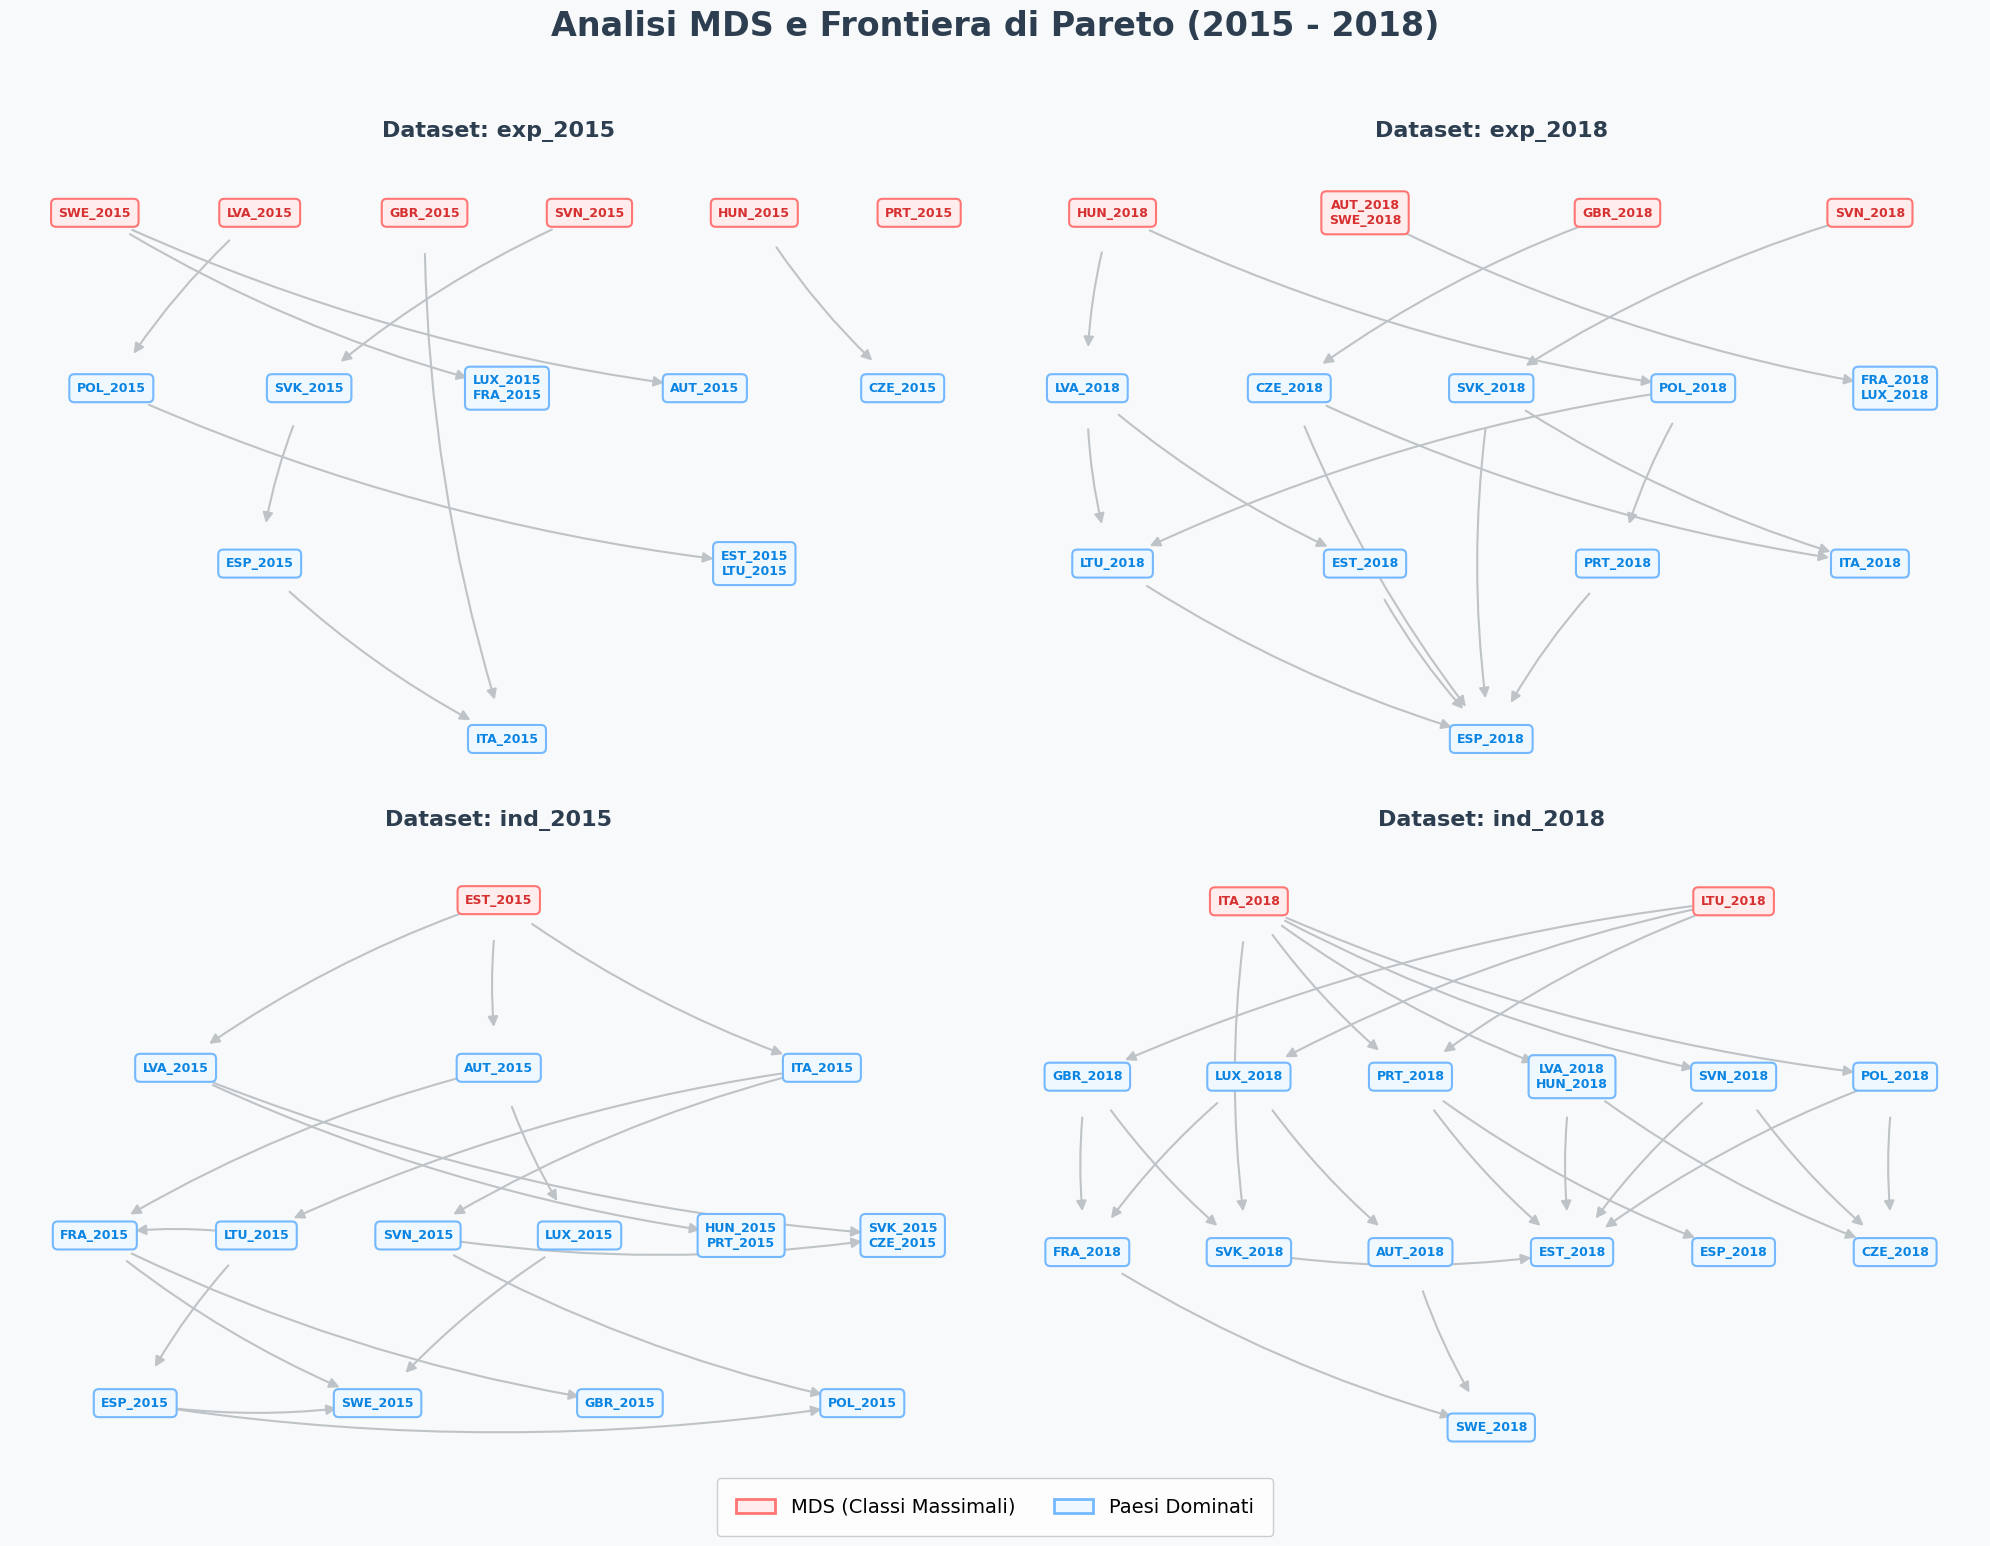

In [43]:
def draw_hasse_on_axis(ax, poset_dict, title):
    """
    Disegna un singolo diagramma di Hasse su uno specifico asse (ax) di matplotlib.
    Include la condensazione dei cicli e il calcolo dell'MDS.
    """
    G = nx.DiGraph()
    G.add_nodes_from(poset_dict['elements'])
    G.add_edges_from(poset_dict['dom_certain'])
    C = nx.condensation(G)
    TR_C = nx.transitive_reduction(C)
    
    Hasse_G = nx.DiGraph()
    mapping = {}
    for n in C.nodes():
        members = list(C.nodes[n]['members'])
        label = "\n".join(members)
        mapping[n] = label
        Hasse_G.add_node(label)
        
    for u, v in TR_C.edges():
        Hasse_G.add_edge(mapping[u], mapping[v])
        
    source_supernodes = [n for n, d in C.in_degree() if d == 0]
    massimali_equivalenti = set()
    for n in source_supernodes:
        massimali_equivalenti.update(C.nodes[n]['members'])
        
    layers = {node: 0 for node in Hasse_G.nodes()}
    sources = [n for n in Hasse_G.nodes() if Hasse_G.in_degree(n) == 0]
    
    for src in sources:
        lengths = nx.single_source_shortest_path_length(Hasse_G, src)
        for target, length in lengths.items():
            if length > layers.get(target, -1):
                layers[target] = length
                
    layer_nodes = {}
    for node, layer in layers.items():
        layer_nodes.setdefault(layer, []).append(node)
        
    pos = {}
    max_layer = max(layer_nodes.keys()) if layer_nodes else 0
    for layer, nodes_in_layer in layer_nodes.items():
        y = max_layer - layer  
        n_nodes = len(nodes_in_layer)
        nodes_in_layer = sorted(nodes_in_layer, key=lambda x: -Hasse_G.out_degree(x))
        for i, node in enumerate(nodes_in_layer):
            x = (i - (n_nodes - 1) / 2.0) * (8.0 / max(1, n_nodes))
            pos[node] = (x, y)


    if len(Hasse_G.edges()) > 0:
        nx.draw_networkx_edges(
            Hasse_G, pos, ax=ax,
            edge_color='#BDC3C7', width=1.5,
            arrows=True, arrowsize=15, arrowstyle='-|>',
            node_size=3500, connectionstyle="arc3,rad=0.08"
        )
    
    
    for node in Hasse_G.nodes():
        is_mds = any(max_el in node for max_el in massimali_equivalenti)
        if is_mds:
            bg_color, border_color, text_color = '#FFECEC', '#FF7675', '#D63031'
        else:
            bg_color, border_color, text_color = '#F0F8FF', '#74B9FF', '#0984E3'
            
        ax.text(
            pos[node][0], pos[node][1], node,
            ha='center', va='center', fontsize=9, fontweight='bold', color=text_color,
            bbox=dict(
                boxstyle="round,pad=0.6,rounding_size=0.4",
                facecolor=bg_color, edgecolor=border_color, linewidth=1.5
            )
        )
        
    ax.set_title(title, fontsize=16, fontweight='bold', color='#2C3E50', pad=15)
    ax.axis('off')

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 16), facecolor='#F8F9FA')
fig.suptitle("Analisi MDS e Frontiera di Pareto (2015 - 2018)", 
             fontsize=24, fontweight='bold', color='#2C3E50', y=0.98)

axes = axes.flatten()

keys_to_plot = sorted(list(data.keys()))

for i, key in enumerate(keys_to_plot):
    draw_hasse_on_axis(axes[i], data[key], title=f"Dataset: {key}")

mds_patch = mpatches.Patch(facecolor='#FFECEC', edgecolor='#FF7675', linewidth=2, label='MDS (Classi Massimali)')
dom_patch = mpatches.Patch(facecolor='#F0F8FF', edgecolor='#74B9FF', linewidth=2, label='Paesi Dominati')
fig.legend(handles=[mds_patch, dom_patch], loc='lower center', ncol=2, 
           fontsize=14, frameon=True, facecolor='white', edgecolor='#BDC3C7', borderpad=1, bbox_to_anchor=(0.5, 0.02))

plt.tight_layout(rect=[0, 0.05, 1, 0.95]) 
plt.show()

In [44]:
def analyze_bottleneck(
    poset_dict: dict,
    country_a: str,
    country_b: str,
    verbose: bool = True,
) -> dict:
    """
    Explain why country_a does NOT certainly dominate country_b.

    For certain dominance, a ≤ b requires hi[a,k] ≤ lo[b,k] for all k.
    A bottleneck is any indicator where hi[a,k] > lo[b,k].

    Parameters
    ----------
    poset_dict : dict
        Output of poset_from_polars().
    country_a, country_b : str
        Element labels (e.g. 'SWE_2018').
    verbose : bool
        Print detailed analysis.

    Returns
    -------
    dict with keys:
        'bottlenecks'   : list of dict — indicators blocking dominance
        'supports'      : list of dict — indicators where a dominates b
        'n_bottlenecks' : int
        'n_supports'    : int
        'dominates'     : bool — True if a certainly dominates b
    """
    intervals = poset_dict["intervals"]
    cols = poset_dict["indicator_cols"]

    if country_a not in intervals or country_b not in intervals:
        raise ValueError(
            f"Element not found. Available: {sorted(intervals.keys())}"
        )

    hi_a = intervals[country_a]["hi"]
    lo_a = intervals[country_a]["lo"]
    hi_b = intervals[country_b]["hi"]
    lo_b = intervals[country_b]["lo"]
    null_a = poset_dict["null_mask"][country_a]
    null_b = poset_dict["null_mask"][country_b]

    bottlenecks = []
    supports = []

    for i, col in enumerate(cols):
        gap = lo_b[i] - hi_a[i]  # positive = b certainly above a on this indicator

        entry = {
            "indicator": col,
            "a_lo": lo_a[i],
            "a_hi": hi_a[i],
            "b_lo": lo_b[i],
            "b_hi": hi_b[i],
            "gap": gap,
            "a_null": bool(null_a[i]),
            "b_null": bool(null_b[i]),
        }

        if hi_a[i] > lo_b[i]:
            # a's best case exceeds b's worst case → blocks certain dominance
            bottlenecks.append(entry)
        else:
            supports.append(entry)

    dominates = len(bottlenecks) == 0

    if verbose:
        a_short = country_a.split("_")[0]
        b_short = country_b.split("_")[0]

        if dominates:
            print(f"{a_short} certainly dominates {b_short} on all {len(cols)} indicators.")
        else:
            print(f"Why {a_short} does NOT certainly dominate {b_short}:")
            print(f"  {len(supports)} indicators support dominance, "
                  f"{len(bottlenecks)} block it.\n")

            print("  BOTTLENECKS (blocking dominance):")
            # Sort by gap (most blocking first)
            for b in sorted(bottlenecks, key=lambda x: x["gap"]):
                null_flag = ""
                if b["a_null"] or b["b_null"]:
                    null_flag = "  [null uncertainty]"
                print(f"    {b['indicator']:30s}  "
                      f"{a_short}=[{b['a_lo']:.1f}, {b['a_hi']:.1f}]  "
                      f"{b_short}=[{b['b_lo']:.1f}, {b['b_hi']:.1f}]  "
                      f"gap={b['gap']:+.1f}{null_flag}")

            if supports:
                print(f"\n  SUPPORTS (a ≤ b holds):")
                for s in sorted(supports, key=lambda x: -x["gap"]):
                    print(f"    {s['indicator']:30s}  "
                          f"{a_short}=[{s['a_lo']:.1f}, {s['a_hi']:.1f}]  "
                          f"{b_short}=[{s['b_lo']:.1f}, {s['b_hi']:.1f}]  "
                          f"gap={s['gap']:+.1f}")

    return {
        "bottlenecks": bottlenecks,
        "supports": supports,
        "n_bottlenecks": len(bottlenecks),
        "n_supports": len(supports),
        "dominates": dominates,
    }

In [45]:
# Single pair
result = analyze_bottleneck(data["ind_2018"], "SVN_2018", "LTU_2018")

# Compare multiple pairs
for a, b in [("SWE_2018", "LTU_2018"), ("SVN_2018", "LTU_2018"), ("GBR_2018", "ITA_2018")]:
    print(f"\n{'='*60}")
    analyze_bottleneck(data["ind_2018"], a, b)

Why SVN does NOT certainly dominate LTU:
  1 indicators support dominance, 3 block it.

  BOTTLENECKS (blocking dominance):
    health_prevention               SVN=[2.0, 2.0]  LTU=[1.0, 1.0]  gap=-1.0
    education_skills                SVN=[2.0, 2.0]  LTU=[1.0, 1.0]  gap=-1.0
    social_wellbeing                SVN=[2.0, 2.0]  LTU=[1.0, 1.0]  gap=-1.0

  SUPPORTS (a ≤ b holds):
    material_protection             SVN=[1.0, 1.0]  LTU=[2.0, 2.0]  gap=+1.0

Why SWE does NOT certainly dominate LTU:
  1 indicators support dominance, 3 block it.

  BOTTLENECKS (blocking dominance):
    health_prevention               SWE=[3.0, 3.0]  LTU=[1.0, 1.0]  gap=-2.0
    material_protection             SWE=[3.0, 3.0]  LTU=[2.0, 2.0]  gap=-1.0
    education_skills                SWE=[2.0, 2.0]  LTU=[1.0, 1.0]  gap=-1.0

  SUPPORTS (a ≤ b holds):
    social_wellbeing                SWE=[1.0, 1.0]  LTU=[1.0, 1.0]  gap=+0.0

Why SVN does NOT certainly dominate LTU:
  1 indicators support dominance, 3 blo

*This notebook is licensed under [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/).*